In [ ]:
import importlib.util, subprocess, sys, os, time, random, warnings, inspect, hashlib

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["WANDB_DISABLED"] = "true"

_REQUIRED = {
    "transformers": "transformers",
    "datasets": "datasets",
    "peft": "peft",
    "accelerate": "accelerate",
    "sklearn": "scikit-learn",
}
_missing = [pkg for mod, pkg in _REQUIRED.items() if importlib.util.find_spec(mod) is None]
if _missing:
    print(f"Installing: {', '.join(_missing)} ...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *_missing], check=True)
    print("Done. (If imports fail below, restart the runtime and re-run.)\n")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix, roc_curve)
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding,
                          EarlyStoppingCallback, set_seed)
from peft import LoraConfig, get_peft_model, TaskType

def _disable_torchao_probe():
    patched = []
    try:
        import peft.import_utils as _piu
        _piu.is_torchao_available = lambda: False
        patched.append("peft.import_utils")
    except Exception:
        pass
    for _name, _mod in list(sys.modules.items()):
        if _name.startswith("peft") and hasattr(_mod, "is_torchao_available"):
            _mod.is_torchao_available = lambda: False
            patched.append(_name)
    return patched

try:
    import torchao as _tao
    _v = getattr(_tao, "__version__", "?")
    if tuple(int(x) for x in _v.split(".")[:2]) < (0, 16):
        print(f"[compat] torchao {_v} < 0.16 -> disabling PEFT's torchao probe: "
              f"{', '.join(_disable_torchao_probe())}")
except Exception:
    _disable_torchao_probe()

SEED        = 42
MODEL_NAME  = "distilbert-base-uncased"
MAX_LEN     = 256
N_TRAIN     = 5000
N_EVAL      = 2000
N_UNSUP     = 3000
EPOCHS      = 2
BATCH       = 16
LR          = 3e-4
FULL_RUN    = False

if FULL_RUN:
    N_TRAIN, N_EVAL, EPOCHS = 25000, 25000, 3

set_seed(SEED); random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("=" * 79)
print(f"device={DEVICE} | torch={torch.__version__} | "
      f"gpu={torch.cuda.get_device_name(0) if DEVICE=='cuda' else 'n/a'}")
print("=" * 79)

t0 = time.time()
raw = load_dataset("stanfordnlp/imdb")
print(raw, f"\nloaded in {time.time()-t0:.1f}s\n")

print("--- example (truncated) ---")
print("label:", raw["train"][0]["label"], "|", raw["train"][0]["text"][:300], "...\n")

first_labels = np.array(raw["train"]["label"][:5])
last_labels  = np.array(raw["train"]["label"][-5:])
print(f"TRAP #1 - split ordering: first 5 labels {first_labels}, "
      f"last 5 labels {last_labels}  -> ALWAYS shuffle before subsampling.")

train_full = raw["train"].shuffle(seed=SEED)
test_full  = raw["test"].shuffle(seed=SEED)
train_ds   = train_full.select(range(min(N_TRAIN, len(train_full))))
eval_ds    = test_full.select(range(min(N_EVAL, len(test_full))))
print(f"   after shuffle+subsample: train balance = "
      f"{np.bincount(train_ds['label'])}, eval balance = {np.bincount(eval_ds['label'])}")

lens = np.array([len(t.split()) for t in train_full["text"]])
q = np.percentile(lens, [50, 75, 90, 95, 99])
print(f"\nTRAP #2 - length (words): median={q[0]:.0f} p75={q[1]:.0f} p90={q[2]:.0f} "
      f"p95={q[3]:.0f} p99={q[4]:.0f} max={lens.max()}")
print(f"   ~{(lens > MAX_LEN*0.75).mean()*100:.1f}% of reviews exceed MAX_LEN={MAX_LEN} "
      f"tokens (rough words->tokens factor 1.3). Section 9 measures what that costs.")

h_tr = {hashlib.md5(t.encode()).hexdigest() for t in raw["train"]["text"]}
h_te = {hashlib.md5(t.encode()).hexdigest() for t in raw["test"]["text"]}
print(f"\nTRAP #3 - leakage: {len(h_tr & h_te)} exact duplicate reviews across "
      f"train/test; {len(raw['train'])-len(h_tr)} dupes inside train itself.")

def clean(t):
    return t.replace("<br />", " ").replace("<br/>", " ").strip()

plt.figure(figsize=(11, 3.2))
plt.subplot(1, 2, 1)
plt.hist(np.clip(lens, 0, 1000), bins=60)
plt.axvline(MAX_LEN, ls="--", color="k", label=f"MAX_LEN={MAX_LEN}")
plt.title("Review length (words, clipped at 1000)"); plt.legend()
plt.subplot(1, 2, 2)
plt.bar(["neg", "pos"], np.bincount(raw["train"]["label"]))
plt.title("Train class balance (perfectly balanced)")
plt.tight_layout(); plt.show()

In [ ]:
print("\n" + "=" * 79 + "\n3. TF-IDF BASELINE\n" + "=" * 79)
Xtr = [clean(t) for t in train_ds["text"]]; ytr = np.array(train_ds["label"])
Xte = [clean(t) for t in eval_ds["text"]];  yte = np.array(eval_ds["label"])

t0 = time.time()
tfidf_clf = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=300_000,
                    sublinear_tf=True, strip_accents="unicode"),
    LogisticRegression(C=8.0, max_iter=2000, n_jobs=-1),
)
tfidf_clf.fit(Xtr, ytr)
p_tfidf = tfidf_clf.predict_proba(Xte)[:, 1]
acc_tfidf = accuracy_score(yte, p_tfidf > 0.5)
auc_tfidf = roc_auc_score(yte, p_tfidf)
print(f"trained in {time.time()-t0:.1f}s -> acc={acc_tfidf:.4f}  auc={auc_tfidf:.4f}")

vec, lr = tfidf_clf.steps[0][1], tfidf_clf.steps[1][1]
feats, coefs = np.array(vec.get_feature_names_out()), lr.coef_[0]
order = np.argsort(coefs)
print("\nmost NEGATIVE n-grams:", ", ".join(feats[order[:12]]))
print("most POSITIVE n-grams:", ", ".join(feats[order[-12:]][::-1]))

print("\n" + "=" * 79 + "\n4. LoRA FINE-TUNING\n" + "=" * 79)
tok = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tok([clean(t) for t in batch["text"]], truncation=True, max_length=MAX_LEN)

tr_tok = (train_ds.map(tokenize, batched=True, remove_columns=["text"])
                  .rename_column("label", "labels"))
ev_tok = (eval_ds.map(tokenize, batched=True, remove_columns=["text"])
                 .rename_column("label", "labels"))

base = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2,
    id2label={0: "NEGATIVE", 1: "POSITIVE"},
    label2id={"NEGATIVE": 0, "POSITIVE": 1},
)
lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=16, lora_alpha=32, lora_dropout=0.05,
    target_modules=["q_lin", "v_lin"],
    modules_to_save=["pre_classifier", "classifier"],
)
try:
    model = get_peft_model(base, lora_cfg)
except ImportError as e:
    _disable_torchao_probe()
    print(f"[compat] retrying after backend probe failure: {e}")
    model = get_peft_model(base, lora_cfg)
model.print_trainable_parameters()

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (probs > 0.5).astype(int)
    return {"accuracy": accuracy_score(labels, preds),
            "f1_macro": f1_score(labels, preds, average="macro"),
            "roc_auc": roc_auc_score(labels, probs)}

_ta = inspect.signature(TrainingArguments.__init__).parameters
_eval_key = "eval_strategy" if "eval_strategy" in _ta else "evaluation_strategy"
ta_kwargs = dict(
    output_dir="./imdb_lora", learning_rate=LR,
    per_device_train_batch_size=BATCH, per_device_eval_batch_size=BATCH * 2,
    num_train_epochs=EPOCHS, weight_decay=0.01, warmup_ratio=0.06,
    logging_steps=50, save_strategy="epoch", save_total_limit=1,
    load_best_model_at_end=True, metric_for_best_model="accuracy",
    fp16=(DEVICE == "cuda"), report_to="none", seed=SEED,
)
ta_kwargs[_eval_key] = "epoch"

_tr = inspect.signature(Trainer.__init__).parameters
_tok_key = "processing_class" if "processing_class" in _tr else "tokenizer"
trainer = Trainer(
    model=model, args=TrainingArguments(**ta_kwargs),
    train_dataset=tr_tok, eval_dataset=ev_tok,
    data_collator=DataCollatorWithPadding(tok),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    **{_tok_key: tok},
)
t0 = time.time()
trainer.train()
print(f"\nfine-tuned in {(time.time()-t0)/60:.1f} min")

In [ ]:
print("\n" + "=" * 79 + "\n5. EVALUATION\n" + "=" * 79)
pred_out = trainer.predict(ev_tok)
p_lora = torch.softmax(torch.tensor(pred_out.predictions), dim=-1).numpy()[:, 1]
y_true = np.array(pred_out.label_ids)
yhat = (p_lora > 0.5).astype(int)

print(classification_report(y_true, yhat, target_names=["neg", "pos"], digits=4))
cm = confusion_matrix(y_true, yhat)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, cm[i, j], ha="center", va="center", fontsize=14)
ax[0].set_xticks([0, 1], ["pred neg", "pred pos"])
ax[0].set_yticks([0, 1], ["true neg", "true pos"]); ax[0].set_title("Confusion matrix")
for name, p in [("TF-IDF", p_tfidf), ("DistilBERT+LoRA", p_lora)]:
    fpr, tpr, _ = roc_curve(y_true, p)
    ax[1].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_true, p):.4f})")
ax[1].plot([0, 1], [0, 1], "k--", lw=0.8)
ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR"); ax[1].set_title("ROC"); ax[1].legend()
plt.tight_layout(); plt.show()

print("\n" + "=" * 79 + "\n6. THRESHOLD & CALIBRATION\n" + "=" * 79)
ths = np.linspace(0.05, 0.95, 91)
accs = [(y_true == (p_lora > t)).mean() for t in ths]
best_t = ths[int(np.argmax(accs))]
print(f"acc@0.50 = {accs[45]:.4f} | best threshold = {best_t:.2f} -> acc = {max(accs):.4f}")

def expected_calibration_error(probs, labels, n_bins=10):
    """ECE: |confidence - accuracy| averaged over confidence bins."""
    conf = np.maximum(probs, 1 - probs)
    correct = (probs > 0.5).astype(int) == labels
    bins = np.linspace(0, 1, n_bins + 1)
    ece, xs, ys = 0.0, [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum() == 0:
            continue
        ece += m.mean() * abs(conf[m].mean() - correct[m].mean())
        xs.append(conf[m].mean()); ys.append(correct[m].mean())
    return ece, np.array(xs), np.array(ys)

ece, cx, cy = expected_calibration_error(p_lora, y_true)
print(f"Expected Calibration Error = {ece:.4f}  (0 = perfectly calibrated)")

plt.figure(figsize=(9, 3.2))
plt.subplot(1, 2, 1); plt.plot(ths, accs); plt.axvline(best_t, ls="--", color="r")
plt.xlabel("threshold"); plt.ylabel("accuracy"); plt.title("Threshold sweep")
plt.subplot(1, 2, 2); plt.plot([0.5, 1], [0.5, 1], "k--", lw=0.8)
plt.plot(cx, cy, "o-"); plt.xlabel("mean confidence"); plt.ylabel("empirical accuracy")
plt.title(f"Reliability diagram (ECE={ece:.3f})")
plt.tight_layout(); plt.show()

In [ ]:
print("\n" + "=" * 79 + "\n7. ERROR ANALYSIS\n" + "=" * 79)
err = pd.DataFrame({
    "text": eval_ds["text"], "y": y_true, "p_pos": p_lora,
    "n_words": [len(t.split()) for t in eval_ds["text"]],
})
err["pred"] = (err.p_pos > 0.5).astype(int)
err["correct"] = err.pred == err.y
err["confidence"] = np.maximum(err.p_pos, 1 - err.p_pos)

print("--- 3 most CONFIDENT mistakes (where the model is confidently wrong) ---")
for _, r in err[~err.correct].nlargest(3, "confidence").iterrows():
    print(f"\n[true={'pos' if r.y else 'neg'} pred={'pos' if r.pred else 'neg'} "
          f"conf={r.confidence:.3f} words={r.n_words}]")
    print(clean(r.text)[:400].replace("\n", " "), "...")

err["bucket"] = pd.qcut(err.n_words, 4, labels=["short", "med", "long", "v.long"])
by_len = err.groupby("bucket", observed=True).agg(acc=("correct", "mean"), n=("correct", "size"))
print("\n--- accuracy by review length (truncation hurts long reviews) ---")
print(by_len.to_string())

print("\n" + "=" * 79 + "\n8. OCCLUSION SALIENCY\n" + "=" * 79)
infer_model = model.merge_and_unload()
infer_model.to(DEVICE).eval()

@torch.no_grad()
def predict_proba(texts, bs=64):
    out = []
    for i in range(0, len(texts), bs):
        enc = tok([clean(t) for t in texts[i:i + bs]], truncation=True,
                  max_length=MAX_LEN, padding=True, return_tensors="pt").to(DEVICE)
        out.append(torch.softmax(infer_model(**enc).logits, dim=-1)[:, 1].cpu().numpy())
    return np.concatenate(out)

def occlusion(text, max_words=60):
    words = clean(text).split()[:max_words]
    base = predict_proba([" ".join(words)])[0]
    variants = [" ".join(words[:i] + words[i + 1:]) for i in range(len(words))]
    dropped = predict_proba(variants)
    return words, base - dropped, base

sample = err[err.correct].nlargest(1, "confidence").iloc[0]
words, contrib, base_p = occlusion(sample.text)
print(f"P(positive) for the full excerpt = {base_p:.3f} "
      f"(true label = {'pos' if sample.y else 'neg'})\n")
top = np.argsort(np.abs(contrib))[-15:]
plt.figure(figsize=(7, 5))
plt.barh(range(len(top)), contrib[top],
         color=["tab:green" if contrib[i] > 0 else "tab:red" for i in top])
plt.yticks(range(len(top)), [words[i] for i in top])
plt.xlabel("Δ P(positive) when the word is removed")
plt.title("Occlusion saliency — green pushes POSITIVE, red pushes NEGATIVE")
plt.tight_layout(); plt.show()

print("\n" + "=" * 79 + "\n9. HEAD vs TAIL TRUNCATION\n" + "=" * 79)
probe = err.nlargest(600, "n_words")
W = 180
head_txt = [" ".join(clean(t).split()[:W]) for t in probe.text]
tail_txt = [" ".join(clean(t).split()[-W:]) for t in probe.text]
yp = probe.y.values
acc_head = ((predict_proba(head_txt) > 0.5).astype(int) == yp).mean()
acc_tail = ((predict_proba(tail_txt) > 0.5).astype(int) == yp).mean()
print(f"on the {len(probe)} longest reviews, using only {W} words:")
print(f"  first {W} words -> acc {acc_head:.4f}")
print(f"  last  {W} words -> acc {acc_tail:.4f}")
print("  Practical takeaway: if the tail wins, feed head+tail to the model or "
      "raise MAX_LEN, rather than blindly truncating from the left.")

[compat] torchao 0.10.0 < 0.16 -> disabling PEFT's torchao probe: peft.import_utils, peft.import_utils, peft.tuners.lora.torchao
device=cuda | torch=2.11.0+cu128 | gpu=Tesla T4
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
}) 
loaded in 2.1s

--- example (truncated) ---
label: 0 | I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h ...

TRAP #1 - split ordering: first 5 labels [0 0 0 0 0], last 5 labels [1 1 1 1 1]  -> ALWAYS shuffle before subsampling.
   after shuffle+subsample: train balance = [2494 25

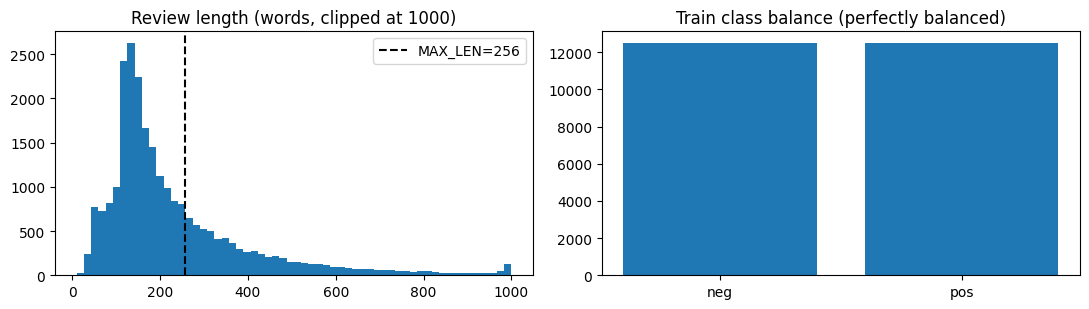


3. TF-IDF BASELINE
trained in 12.3s -> acc=0.8730  auc=0.9510

most NEGATIVE n-grams: bad, worst, poor, the worst, waste, awful, no, nothing, boring, terrible, oh, just
most POSITIVE n-grams: great, best, excellent, the best, very, love, wonderful, amazing, perfect, fun, also, job

4. LoRA FINE-TUNING


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 887,042 || all params: 67,842,052 || trainable%: 1.3075


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Roc Auc
1,0.317712,0.332349,0.865500,0.864533,0.956415
2,0.249692,0.263375,0.890000,0.889975,0.960412



fine-tuned in 1.1 min

5. EVALUATION


              precision    recall  f1-score   support

         neg     0.9021    0.8750    0.8883      1000
         pos     0.8786    0.9050    0.8916      1000

    accuracy                         0.8900      2000
   macro avg     0.8904    0.8900    0.8900      2000
weighted avg     0.8904    0.8900    0.8900      2000



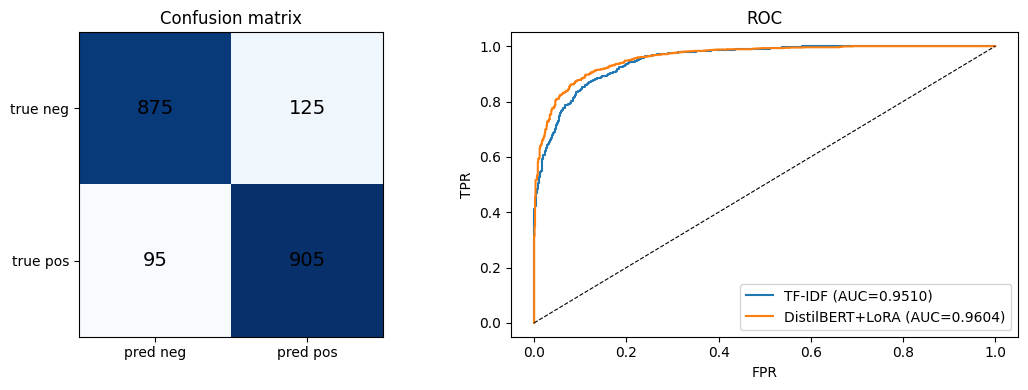


6. THRESHOLD & CALIBRATION
acc@0.50 = 0.8900 | best threshold = 0.55 -> acc = 0.8925
Expected Calibration Error = 0.0273  (0 = perfectly calibrated)


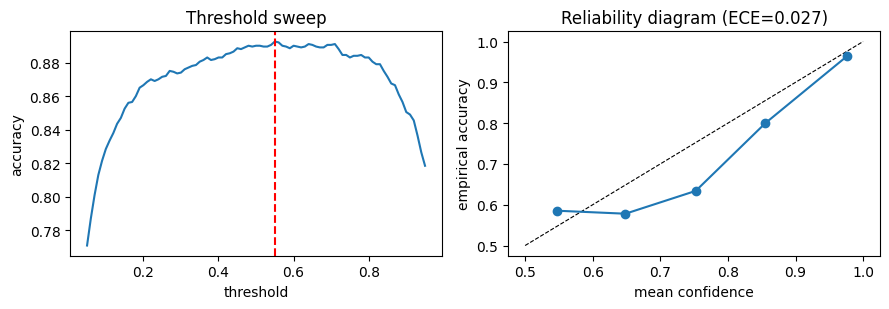


7. ERROR ANALYSIS
--- 3 most CONFIDENT mistakes (where the model is confidently wrong) ---

[true=neg pred=pos conf=0.993 words=121]
Greyfriars Bobby was NOT a westie - Bobby was a skye terrier. A highlight of my childhood day trips to Edinburgh was to go to the monument to Bobby. I grew up with the story of the valiant and loyal little dog, as every child in my generation did, and I remember lining up with my mum outside the cinema - with many, many other Dundee children and their mums - to see the wonderful Disney film. How c ...

[true=neg pred=pos conf=0.991 words=414]
Ha ha. - oh no - what to say about this film? Yes - green eggs and ham makes more sense than this movie. Where does one start? A lot of the good stuff has already been said - so I won't divulge into the same territory. I believe you already have the movie summary - so I won't paraphrase the movie.  First - let's start the with good.  1). If you like psychological thrillers that make you think (as  ...

[true=pos pre

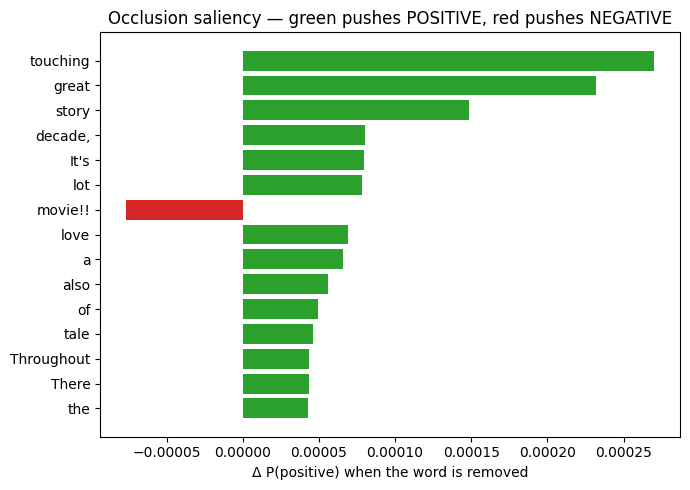


9. HEAD vs TAIL TRUNCATION
on the 600 longest reviews, using only 180 words:
  first 180 words -> acc 0.8500
  last  180 words -> acc 0.8517
  Practical takeaway: if the tail wins, feed head+tail to the model or raise MAX_LEN, rather than blindly truncating from the left.

10. PSEUDO-LABELLING
kept 1743/3000 pseudo-labels at conf>0.95 (balance: [811 932])
TF-IDF baseline      : 0.8730
TF-IDF + pseudo-labels: 0.8725  (Δ -0.0005)
Caveat: gains are bounded by the teacher. Self-training also amplifies the teacher's biases — always validate on clean, held-out data.

11. SAVE & INFER


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved merged model to ./imdb-distilbert-lora-merged/  (load with AutoModelForSequenceClassification.from_pretrained('./imdb-distilbert-lora-merged'))
  P(pos)=0.034 -> NEGATIVE | A masterclass in tension. The final act left the whole theatre silent.
  P(pos)=0.003 -> NEGATIVE | Two hours I will never get back. Wooden acting, incoherent plot.
  P(pos)=0.116 -> NEGATIVE | It's not the disaster the trailer promised, but it never really lands either.

SUMMARY (n_train=5000, n_eval=2000, max_len=256)
                 model  accuracy  roc_auc
       TF-IDF + LogReg    0.8730 0.951049
TF-IDF + pseudo-labels    0.8725      NaN
     DistilBERT + LoRA    0.8900 0.960412

NEXT EXPERIMENTS
  - Set FULL_RUN = True for the real 25k/25k benchmark (~40 min on a T4).
  - Swap MODEL_NAME to 'roberta-base' (target_modules=['query','value']) or
    'answerdotai/ModernBERT-base' for an 8k context window — no truncation.
  - Head+tail truncation: first 128 + last 128 tokens, motivated by section 9.
  - Abla

In [2]:
print("\n" + "=" * 79 + "\n10. PSEUDO-LABELLING\n" + "=" * 79)
unsup = raw["unsupervised"].shuffle(seed=SEED).select(range(N_UNSUP))
p_uns = predict_proba(unsup["text"])
keep = (p_uns > 0.95) | (p_uns < 0.05)
pl_texts = [clean(t) for t, k in zip(unsup["text"], keep) if k]
pl_labels = (p_uns[keep] > 0.5).astype(int)
print(f"kept {keep.sum()}/{N_UNSUP} pseudo-labels at conf>0.95 "
      f"(balance: {np.bincount(pl_labels)})")

aug = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=300_000,
                    sublinear_tf=True, strip_accents="unicode"),
    LogisticRegression(C=8.0, max_iter=2000, n_jobs=-1),
).fit(Xtr + pl_texts, np.concatenate([ytr, pl_labels]))
acc_aug = accuracy_score(yte, aug.predict(Xte))
print(f"TF-IDF baseline      : {acc_tfidf:.4f}")
print(f"TF-IDF + pseudo-labels: {acc_aug:.4f}  (Δ {acc_aug-acc_tfidf:+.4f})")
print("Caveat: gains are bounded by the teacher. Self-training also amplifies "
      "the teacher's biases — always validate on clean, held-out data.")

print("\n" + "=" * 79 + "\n11. SAVE & INFER\n" + "=" * 79)
SAVE_DIR = "./imdb-distilbert-lora-merged"
infer_model.save_pretrained(SAVE_DIR); tok.save_pretrained(SAVE_DIR)
print(f"saved merged model to {SAVE_DIR}/  (load with "
      f"AutoModelForSequenceClassification.from_pretrained('{SAVE_DIR}'))")

demos = [
    "A masterclass in tension. The final act left the whole theatre silent.",
    "Two hours I will never get back. Wooden acting, incoherent plot.",
    "It's not the disaster the trailer promised, but it never really lands either.",
]
for d, p in zip(demos, predict_proba(demos)):
    print(f"  P(pos)={p:.3f} -> {'POSITIVE' if p > 0.5 else 'NEGATIVE'} | {d}")

print("\n" + "=" * 79)
print(f"SUMMARY (n_train={N_TRAIN}, n_eval={N_EVAL}, max_len={MAX_LEN})")
print("=" * 79)
print(pd.DataFrame([
    {"model": "TF-IDF + LogReg", "accuracy": acc_tfidf, "roc_auc": auc_tfidf},
    {"model": "TF-IDF + pseudo-labels", "accuracy": acc_aug, "roc_auc": float("nan")},
    {"model": "DistilBERT + LoRA", "accuracy": accuracy_score(y_true, yhat),
     "roc_auc": roc_auc_score(y_true, p_lora)},
]).to_string(index=False))

print("""
NEXT EXPERIMENTS
  - Set FULL_RUN = True for the real 25k/25k benchmark (~40 min on a T4).
  - Swap MODEL_NAME to 'roberta-base' (target_modules=['query','value']) or
    'answerdotai/ModernBERT-base' for an 8k context window — no truncation.
  - Head+tail truncation: first 128 + last 128 tokens, motivated by section 9.
  - Ablate LoRA rank r in {4, 8, 16, 64} and plot accuracy vs trainable params.
  - Replace the pseudo-label teacher with an ensemble and iterate self-training.
  - Push to the Hub: huggingface_hub.login() then infer_model.push_to_hub(...).
""")